# Por que equações diferenciais?

Equações diferenciais estão em todo lugar. Sempre que alguma quantidade muda ao longo do tempo (ou do espaço) obedecendo a alguma lei física, química, biológica ou econômica, o resultado quase sempre é uma equação diferencial. Elas são a linguagem matemática usada para descrever como o universo funciona: do movimento dos planetas à previsão do tempo, de circuitos elétricos a epidemias, de pontes que vibram a mercados financeiros.

A seguir, alguns exemplos grandiosos — equações que descrevem fenômenos que moldam o mundo, e o universo, à nossa volta.

## O movimento dos planetas — Gravitação de Newton

A lei da gravitação universal de Newton, combinada com sua segunda lei do movimento, leva a uma equação diferencial para a posição $\vec r(t)$ de um corpo orbitando outro — por exemplo, um planeta ao redor do Sol:

$$
\ddot{\vec r} = -\frac{GM}{|\vec r|^{3}}\,\vec r.
$$

É uma equação diferencial de **segunda ordem** (envolve $\ddot{\vec r} = \vec r''$), e suas soluções são exatamente as órbitas elípticas descritas pelas Leis de Kepler. É essa mesma equação, com pequenos ajustes, que a NASA resolve numericamente para planejar a trajetória de uma sonda até Marte.

![A Terra vista do espaço, missão Apollo 17](https://commons.wikimedia.org/wiki/Special:FilePath/The_Earth_seen_from_Apollo_17.jpg)

*Fonte: NASA, Apollo 17 (1972) — domínio público.*

## A previsão do tempo — Equações de Navier–Stokes

O movimento de qualquer fluido — o ar da atmosfera, a água dos oceanos, o sangue nas veias — é descrito pelas **equações de Navier–Stokes**:

$$
\rho\left(\frac{\partial \vec v}{\partial t} + (\vec v\cdot\nabla)\vec v\right) = -\nabla p + \mu\nabla^2\vec v + \rho\,\vec g.
$$

Diferente do exemplo anterior, essa é uma **equação diferencial parcial** (EDP): a incógnita $\vec v(x,y,z,t)$ depende de várias variáveis — posição *e* tempo — e a equação envolve derivadas parciais em relação a cada uma delas. Toda previsão do tempo do mundo, no fundo, é uma simulação numérica dessa equação rodando em um supercomputador, sobre uma grade de pontos cobrindo a atmosfera inteira. (Curiosidade: ainda não sabemos provar, em geral, se essas equações sempre têm solução bem-comportada — é um dos sete "Problemas do Milênio", com um prêmio de US\$ 1 milhão para quem resolver.)

![Furacão Isabel, fotografado da Estação Espacial Internacional](https://commons.wikimedia.org/wiki/Special:FilePath/Hurricane_Isabel_from_ISS.jpg)

*Fonte: NASA / Estação Espacial Internacional, Expedição 7 (2003) — domínio público.*

## Buracos negros e ondas gravitacionais — Relatividade Geral

As equações de campo de Einstein,

$$
G_{\mu\nu} = \frac{8\pi G}{c^4}\,T_{\mu\nu},
$$

são um sistema de equações diferenciais parciais que relacionam a curvatura do espaço-tempo (lado esquerdo) à distribuição de massa e energia (lado direito). A partir delas, Einstein previu, em 1915, a existência de buracos negros e de ondas gravitacionais — décadas antes de qualquer evidência observacional. As ondas gravitacionais só foram detectadas em 2015 (observatório LIGO), e a primeira imagem real de um buraco negro só foi obtida em 2019: exatamente a "sombra" prevista pelas soluções dessa equação.

![Primeira imagem de um buraco negro (M87*), obtida pelo Event Horizon Telescope](https://commons.wikimedia.org/wiki/Special:FilePath/Black_hole_-_Messier_87_crop_max_res.jpg)

*Fonte: Event Horizon Telescope Collaboration (2019) — CC BY 4.0.*

## Epidemias — o modelo SIR

Como uma doença se espalha por uma população? O modelo mais simples e mais usado é o **modelo SIR** (Suscetíveis–Infectados–Recuperados), um sistema de três equações diferenciais não lineares:

$$
\begin{aligned}
S' &= -\beta\,\frac{SI}{N},\\
I' &= \beta\,\frac{SI}{N} - \gamma I,\\
R' &= \gamma I,
\end{aligned}
$$

onde $S(t)$, $I(t)$ e $R(t)$ são o número de suscetíveis, infectados e recuperados (com $S+I+R=N$ constante), $\beta$ é a taxa de infecção (quão facilmente a doença se transmite a cada contato) e $\gamma$ é a taxa de recuperação.

A razão $R_0 = \beta/\gamma$ — o famoso "número básico de reprodução", tão citado durante a pandemia de Covid-19 — determina se a epidemia decola ($R_0>1$) ou se extingue sozinha ($R_0<1$). Veja como o mesmo modelo, com diferentes valores de $\beta$ (e portanto de $R_0$), produz picos de infecção com magnitudes completamente diferentes:

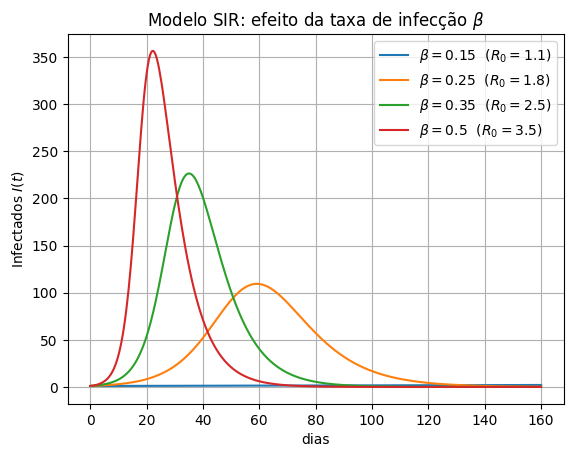

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def sir(y, t, beta, gamma, N):
    S, I, R = y
    dS = -beta*S*I/N
    dI = beta*S*I/N - gamma*I
    dR = gamma*I
    return [dS, dI, dR]

N = 1000
I0, R0_ = 1, 0
S0 = N - I0 - R0_
t = np.linspace(0, 160, 400)
gamma = 1/7  # ~7 dias até a recuperação

betas = [0.15, 0.25, 0.35, 0.5]
for beta in betas:
    sol = odeint(sir, [S0, I0, R0_], t, args=(beta, gamma, N))
    I = sol[:, 1]
    plt.plot(t, I, label=fr"$\beta={beta}$  ($R_0={beta/gamma:.1f}$)")

plt.xlabel("dias"); plt.ylabel("Infectados $I(t)$")
plt.title(r"Modelo SIR: efeito da taxa de infecção $\beta$")
plt.legend()
plt.grid(True)
plt.show()

Quanto maior $\beta$ (doença mais contagiosa), mais alto e mais rápido é o pico de infectados — exatamente o comportamento que motivou as medidas de distanciamento social: reduzir $\beta$ "achata a curva".

## Circuitos elétricos — a equação RLC

Em um circuito elétrico com um resistor ($R$), um indutor ($L$) e um capacitor ($C$) em série, a carga $q(t)$ no capacitor obedece a

$$
L\,q'' + R\,q' + \frac{1}{C}\,q = E(t),
$$

onde $E(t)$ é a tensão da fonte. Compare com a equação de um sistema massa-mola-amortecedor,

$$
m\,x'' + c\,x' + k\,x = F(t):
$$

são **exatamente a mesma equação diferencial**, apenas com nomes diferentes para as constantes! Essa é uma das ideias mais bonitas das equações diferenciais: sistemas físicos completamente diferentes — um circuito eletrônico e uma mola mecânica — são descritos pela mesma matemática, e se comportam exatamente da mesma forma. Dependendo dos valores das constantes, a resposta livre (sem fonte) pode ser oscilatória, crítica, ou suave:

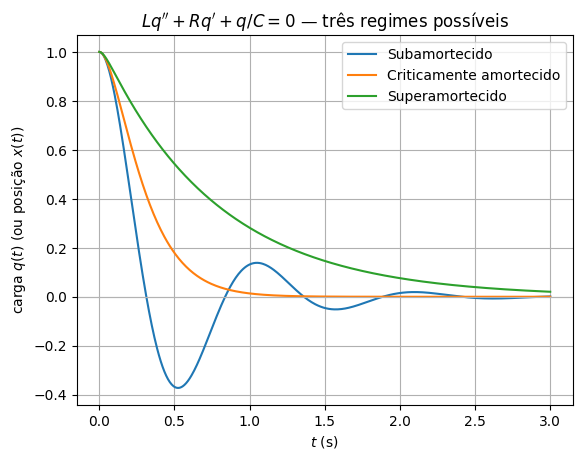

In [ ]:
def osc(y, t, c, k, m=1):
    x, v = y
    return [v, -(c/m)*v - (k/m)*x]

m = 1
k = (2*np.pi)**2
c_crit = 2*np.sqrt(k*m)
t = np.linspace(0, 3, 500)

for label, c in [("Subamortecido", 0.3*c_crit),
                  ("Criticamente amortecido", c_crit),
                  ("Superamortecido", 2.5*c_crit)]:
    sol = odeint(osc, [1, 0], t, args=(c, k))
    plt.plot(t, sol[:, 0], label=label)

plt.axhline(0, color="0.7", linewidth=0.8)
plt.xlabel("$t$ (s)"); plt.ylabel(r"carga $q(t)$ (ou posição $x(t)$)")
plt.title(r"$L q'' + Rq' + q/C = 0$ — três regimes possíveis")
plt.legend()
plt.grid(True)
plt.show()

Vamos entender exatamente de onde vêm esses três comportamentos — e como identificá-los sem simular nada — quando estudarmos equações lineares de segunda ordem.

## Controle — mantendo um sistema no lugar certo

Muitos sistemas de engenharia precisam ser **controlados**: um piloto automático deve manter um avião em altitude constante, um foguete precisa pousar exatamente sobre a plataforma, e o cruise control do seu carro deve manter a velocidade constante mesmo numa subida. Em todos esses casos, um sensor mede o estado atual do sistema, compara com o valor desejado (o *setpoint*), e aplica uma força corretiva — e o resultado, mais uma vez, é uma equação diferencial.

Um controlador **PID** (proporcional–integral–derivativo), o mais usado na indústria, aplica uma força de correção

$$
u(t) = k_p\,e(t) + k_i\int_0^t e(s)\,ds + k_d\,e'(t), \qquad e(t) = v_{\text{ref}} - v(t),
$$

onde $e(t)$ é o erro entre o valor desejado e o valor atual. Veja a diferença entre um carro tentando manter $25\,\text{m/s}$ ao subir uma ladeira sem nenhum controle ativo, e o mesmo carro com um controlador PI:

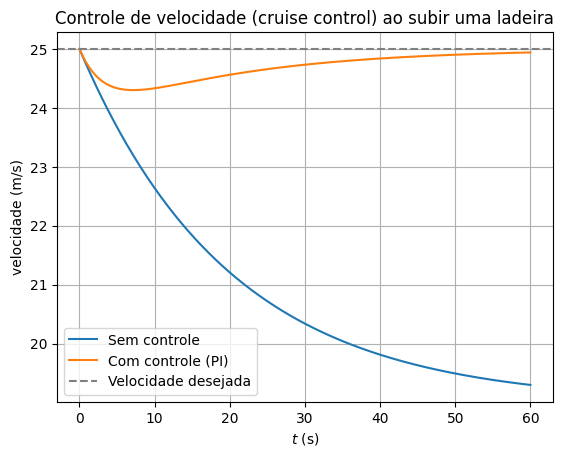

In [ ]:
def cruise(y, t, b, m, F0, F_hill, kp, ki, v_ref, controlled):
    v, integral = y
    u = kp*(v_ref - v) + ki*integral if controlled else 0.0
    dv = (F0 + u - b*v - F_hill)/m
    dintegral = v_ref - v
    return [dv, dintegral]

m, b = 1000, 50       # massa (kg), coeficiente de arrasto/atrito
v_ref = 25             # velocidade desejada (m/s)
F0 = b*v_ref           # empuxo do motor que mantém v_ref em plano
F_hill = 300           # força extra exigida por uma ladeira, a partir de t=0

t = np.linspace(0, 60, 400)
sol_livre = odeint(cruise, [v_ref, 0], t, args=(b, m, F0, F_hill, 0, 0, v_ref, False))
sol_pid   = odeint(cruise, [v_ref, 0], t, args=(b, m, F0, F_hill, 300, 15, v_ref, True))

plt.plot(t, sol_livre[:, 0], label="Sem controle")
plt.plot(t, sol_pid[:, 0], label="Com controle (PI)")
plt.axhline(v_ref, color="gray", linestyle="--", label="Velocidade desejada")
plt.xlabel("$t$ (s)"); plt.ylabel("velocidade (m/s)")
plt.title("Controle de velocidade (cruise control) ao subir uma ladeira")
plt.legend()
plt.grid(True)
plt.show()

Sem controle, a força extra da ladeira faz o carro perder velocidade e estabilizar bem abaixo do valor desejado. Com o controlador, o erro é continuamente corrigido até a velocidade convergir de volta para o valor de referência.

## Vibração e ressonância — por que pontes e prédios podem entrar em colapso

Toda estrutura — uma ponte, um prédio, a asa de um avião — tem uma ou mais **frequências naturais de vibração** $\omega_0$, determinadas por sua massa e rigidez. Se uma força externa oscilante (vento, passos sincronizados de pedestres, um terremoto) atua sobre a estrutura numa frequência $\omega$ próxima de $\omega_0$, a amplitude da vibração pode crescer dramaticamente — um fenômeno chamado **ressonância**:

$$
m\,x'' + c\,x' + k\,x = F_0\cos(\omega t).
$$

Foi a ressonância, amplificada por ventos moderados, que derrubou a ponte de Tacoma Narrows em 1940 (um caso clássico, ainda estudado em todo curso de engenharia), e que obrigou o fechamento da Millennium Bridge em Londres, em 2000, poucos dias após a inauguração, por causa da vibração excessiva causada pelos próprios pedestres. Veja como a amplitude da resposta depende da proximidade entre $\omega$ e $\omega_0$, e como o amortecimento $\zeta$ controla o tamanho do pico:

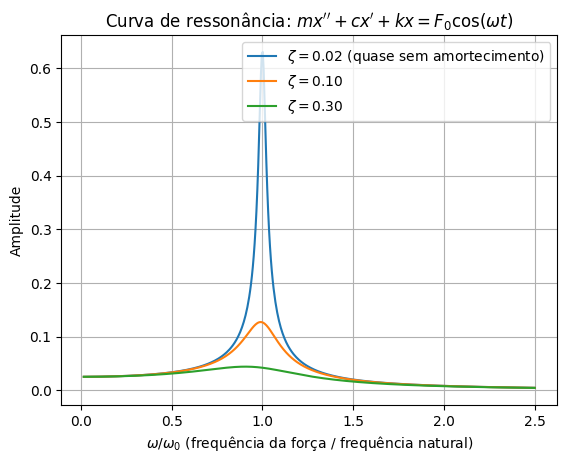

In [ ]:
m, k = 1, (2*np.pi)**2
omega0 = np.sqrt(k/m)
omega = np.linspace(0.1, 2.5*omega0, 500)
F0 = 1

for zeta, label in [(0.02, r"$\zeta=0.02$ (quase sem amortecimento)"),
                      (0.10, r"$\zeta=0.10$"),
                      (0.30, r"$\zeta=0.30$")]:
    c = zeta*2*np.sqrt(k*m)
    amp = F0/np.sqrt((k - m*omega**2)**2 + (c*omega)**2)
    plt.plot(omega/omega0, amp, label=label)

plt.xlabel(r"$\omega/\omega_0$ (frequência da força / frequência natural)")
plt.ylabel("Amplitude")
plt.title(r"Curva de ressonância: $mx'' + cx' + kx = F_0\cos(\omega t)$")
plt.legend()
plt.grid(True)
plt.show()

Quanto menor o amortecimento, mais estreito e mais alto é o pico de ressonância — e mais perigosa é a estrutura se a frequência de excitação chegar perto de $\omega_0$. Projetar estruturas para evitar ressonância é uma das aplicações mais diretas de equações diferenciais na engenharia civil e mecânica.

O mesmo tipo de raciocínio — escrever uma equação que relaciona uma quantidade e sua taxa de variação — aparece em praticamente qualquer área da engenharia e das ciências: o crescimento de uma população, a difusão de calor em uma peça metálica, o preço de uma opção financeira, os níveis de energia de um átomo na mecânica quântica, o comportamento de um robô ou de uma rede neural. Ao longo deste curso, vamos aprender a construir e resolver esses modelos — começando pelos mais simples, mas sempre de olho no quanto eles conseguem descrever.